In [ ]:
!pip install openai==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.106.0
    Uninstalling openai-1.106.0:
      Successfully uninstalled openai-1.106.0


In [ ]:
import pandas as pd
import os
import numpy as np
from sentence_transformers import SentenceTransformer
import nltk
import zipfile
import os
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from google.colab import files
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1_talents_1-500.csv to 1_talents_1-500.csv


In [ ]:
# Define file paths and columns of interest short datasets
resume_files = ['1_talents_1-500.csv']
job_files = ['Administration, economics and law.csv']

In [ ]:
#Define which columns to use from each file type
resume_columns = ['about', 'tools', 'skills', 'location', 'languages', 'educations', 'experiences', 'certifications', 'drivers_license']
job_columns = ['title_en', 'description_en', 'work_model', 'employment_type', 'drivers_license', 'location']

In [ ]:
#Define which columns to use from each file type
resume_columns = ['about', 'tools', 'skills', 'educations', 'experiences', 'certifications']
job_columns = ['title_en']

In [ ]:
def load_text_from_csvs(file_list, columns_to_use):
    """
    file_list: list of file names (strings)
    columns_to_use: list of column names to extract text from
    """
    all_texts = []

    for file_name in file_list:
        if not os.path.exists(file_name):
            print(f"Warning: File {file_name} not found. Skipping.")
            continue

        try:
            df = pd.read_csv(file_name, encoding='utf-8-sig')

            valid_columns = [col for col in columns_to_use if col in df.columns]
            if not valid_columns:
                print(f"Warning: None of the specified columns found in {file_name}")
                continue

            for _, row in df.iterrows():
                combined_text = ' '.join(
                    str(row[col]) for col in valid_columns
                    if pd.notna(row[col]) and str(row[col]).strip() != ''
                )
                if combined_text.strip():
                    all_texts.append(combined_text)

        except Exception as e:
            print(f"Error processing {file_name}: {str(e)}")

    return all_texts

In [ ]:
#Load the texts
resume_texts = load_text_from_csvs(resume_files, resume_columns)
job_texts = load_text_from_csvs(job_files, job_columns)

print(f"Loaded {len(resume_texts)} resume texts and {len(job_texts)} job texts")

Loaded 498 resume texts and 100 job texts


In [ ]:
resume_texts

["I am a goal-oriented university engineer in electrical engineering with a strong self-sufficient ability. My joy and social skills make me a prominent team player, while my structured and methodological approach ensures accuracy and efficiency in my work tasks. I thrive in new and varied situations and have the ability to quickly adapt to different work environments. ['LabVIEW', 'Python', 'Matlab', 'LTSpice', 'SolidWorks', 'Arduino', 'PowerWorld Simulator'] ['Electrical engineering', 'Teamwork', 'Adaptability', 'Social skills'] [{'course': 'Högskoleingenjör i elektroteknik', 'degree': 'Bachelor', 'end_date': '2023-01-01', 'location': 'Uppsala', 'start_date': '2020-01-01', 'university': 'Uppsala universitet'}, {'course': 'Gymnasieexamen på komvux', 'degree': 'High School Diploma', 'end_date': '2018-01-01', 'location': 'Uppsala', 'start_date': '2016-01-01', 'university': None}, {'course': 'Vård och omsorg', 'degree': 'Vocational Training', 'end_date': '2014-01-01', 'location': 'Uppsala

In [ ]:
import pandas as pd
from tqdm import tqdm

# Turn the loaded texts into a DataFrame
resume_df_final = pd.DataFrame({"resume_summary": resume_texts})
jobs_df_final = pd.DataFrame({"job_summary": job_texts})



In [ ]:
jobs_df_final

,job_summary
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
95,Executive assistant
96,Executive Assistant & Business Support
97,Legal Counsel
98,Departmental Controller for NCC Infrastructure


In [ ]:
resume_df_final

,resume_summary
0,I am a goal-oriented university engineer in el...
1,Master's degree in Tribology (TRIBOS+ Joint De...
2,Currently studying at Universidad Francisco de...
3,Motivated and ambitious mechanical engineer wi...
4,"I am an enthusiastic kind of person, exception..."
...,...
493,Passionate automation expert with 4+ years pro...
494,Enthusiastic General Electrician & solar insta...
495,Experienced and reliable leader with over 25 y...
496,[{'course': 'Social Science Program with a foc...


In [ ]:
!pip install --upgrade scipy

In [ ]:
# Download necessary NLTK resources (only need to run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
def preprocess_text(text):
    """
    Preprocesses a given text string for NLP tasks. This includes cleaning the text,
    tokenizing, removing stopwords, and lemmatizing the words.

    Args:
    text (str): The text string to preprocess.

    Returns:
    str: The preprocessed text.
    """
    if not isinstance(text, str):  # Safeguard against non-string input like NaN
        return ""

     # 1. Add spaces around tags, then remove them
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # 4. Remove special characters (keep only words and whitespace)
    text = re.sub(r'[^\w\s]', '', text)

    #5 Trip out all non-ASCII characters like â, €, ™, etc., that appear due to encoding mismatches
    text = text.encode('ascii', 'ignore').decode()

    text = text.lower()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_text)

In [ ]:
# Apply preprocessing
# Keep original resume text in a new column
resume_df_final['Resume_original'] = resume_df_final['resume_summary']

# Apply preprocessing only on 'Resume'
resume_df_final['resume_summary'] = resume_df_final['resume_summary'].apply(preprocess_text)


In [ ]:
resume_df_final

,resume_summary,Resume_original
0,goaloriented university engineer electrical en...,I am a goal-oriented university engineer in el...
1,master degree tribology tribos joint degree er...,Master's degree in Tribology (TRIBOS+ Joint De...
2,currently studying universidad francisco de vi...,Currently studying at Universidad Francisco de...
3,motivated ambitious mechanical engineer 7 year...,Motivated and ambitious mechanical engineer wi...
4,enthusiastic kind person exceptional communica...,"I am an enthusiastic kind of person, exception..."
...,...,...
493,passionate automation expert 4 year programmin...,Passionate automation expert with 4+ years pro...
494,enthusiastic general electrician solar install...,Enthusiastic General Electrician & solar insta...
495,experienced reliable leader 25 year various le...,Experienced and reliable leader with over 25 y...
496,course social science program focus behavioral...,[{'course': 'Social Science Program with a foc...


In [ ]:
jobs_df_final

,job_summary
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
95,Executive assistant
96,Executive Assistant & Business Support
97,Legal Counsel
98,Departmental Controller for NCC Infrastructure


In [ ]:
def drop_duplicates(df, column_name):
    """
    Drops duplicates based on a specified column from the DataFrame.

    Args:
    df (pd.DataFrame): The DataFrame from which to remove duplicates.
    column_name (str): The name of the column based on which duplicates will be identified.

    Returns:
    pd.DataFrame: DataFrame with duplicates removed based on the specified column.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    original_size = df.shape[0]
    df_cleaned = df.drop_duplicates(subset=[column_name])
    new_size = df_cleaned.shape[0]

    print(f"Dropped {original_size - new_size} duplicates from '{column_name}'. New dataset size: {new_size}")

    return df_cleaned

In [ ]:
df = drop_duplicates(df, column_name='Resume')

NameError: name 'df' is not defined

In [ ]:
'''#resume_df_final = df[['Resume']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary'})
resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary','Category': 'Category_original'})
jobs_df_final = df[['Category']].rename(columns={'Category': 'job_summary'})'''

NameError: name 'df' is not defined

In [ ]:
# Import the packages and set some parameters

from tqdm.notebook import tqdm
import json
import pandas as pd
import os
import requests
import numpy as np
import time
import pickle

In [ ]:
import openai

# Set parameters for Azure openai
openai_rg_name = 'openai-lab'
openai_svc_name = 'openai-lab-rm'
openai.api_type = "azure"
openai.api_version = "2023-03-15-preview"

# The openai endpoint and key that you acquire when setting up Azure openai.
openai.api_base = "https://openaialexandra.openai.azure.com/"
#openai.api_key = os.getenv("OPENAI_API_KEY")
openai.api_key = "1UCwRNRoRgKrOpzvgzFObYi20I3mkwnud6GbidjreE1F54vF28AVJQQJ99BHACfhMk5XJ3w3AAABACOG0CsP"
#openai.api_key = os.getenv("job_resume_key")

# Define the model for summarizing CV documents. The model deployed here is a GPT-3.5-turbo.
text_summarization_model = "gpt-35-turbo"
embedding_model = "text-embedding-ada-002"         # deployed name in Azure

In [ ]:
def get_embedding(text, deployment_id=embedding_model):
    result = openai.Embedding.create(
        deployment_id=deployment_id,
        input=text
    )
    return np.array(result["data"][0]["embedding"])


In [ ]:
def encode_column(df, column, batch_size=16, encoded_column_suffix="_encoded"):
    vectors = []
    for start in tqdm(range(0, len(df), batch_size), desc=f"Embedding {column}"):
        batch_texts = df[column].iloc[start:start+batch_size].tolist()
        batch_embeddings = [
            get_embedding(text, embedding_model) for text in batch_texts
        ]
        vectors.extend(batch_embeddings)
    df[column + encoded_column_suffix] = vectors
    return df


In [ ]:
# Split Function
# -------------------
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        df_shuffled.iloc[:train_end].reset_index(drop=True),
        df_shuffled.iloc[train_end:val_end].reset_index(drop=True),
        df_shuffled.iloc[val_end:].reset_index(drop=True),
    )


In [ ]:
# Evaluation Run
# -------------------
def perform_evaluation_run(resume_df, jobs_df, random_seed=42, similarity_threshold=0.7):
    # Split into train/val/test
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Encode only test sets
    resume_test = encode_column(resume_test, "resume_summary")
    jobs_test = encode_column(jobs_test, "job_summary")

    # Convert to numpy
    resume_test_embeds = np.vstack(resume_test["resume_summary_encoded"].values)
    jobs_test_embeds = np.vstack(jobs_test["job_summary_encoded"].values)

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect matches
    results = []
    for r_idx in range(similarity_matrix.shape[0]):
        for j_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[r_idx, j_idx]
            results.append({
                "resume_index": r_idx,
                "job_index": j_idx,
                "similarity_score": score,
                "resume_summary": resume_test.iloc[r_idx]["resume_summary"],
                "resume_original": resume_test.iloc[r_idx]["Resume_original"],
                "category_original": resume_test.iloc[r_idx]["Category_original"],
                #"job_summary": jobs_test.iloc[j_idx]["job_summary"],
                "predicted_job_category": jobs_test.iloc[j_idx]["job_summary"],
                "is_correct": score >= similarity_threshold
            })

    matches_df = pd.DataFrame(results)

    # Metrics
    metrics = {
        "avg_similarity": matches_df["similarity_score"].mean(),
        "median_similarity": matches_df["similarity_score"].median(),
        "std_similarity": matches_df["similarity_score"].std(),
        "accuracy": matches_df["is_correct"].mean(),
        "num_matches": len(matches_df),
        "num_correct_matches": matches_df["is_correct"].sum(),
        "pct_correct_matches": matches_df["is_correct"].mean() * 100,
    }

    return metrics, matches_df

In [ ]:
# -------------------
# Embedding Functions
# -------------------
def get_embedding(text, deployment_id=embedding_model):
    result = openai.Embedding.create(
        deployment_id=deployment_id,
        input=text
    )
    return np.array(result["data"][0]["embedding"])


In [ ]:
def encode_column(df, column, batch_size=16, encoded_column_suffix="_encoded"):
    vectors = []
    for start in tqdm(range(0, len(df), batch_size), desc=f"Embedding {column}"):
        batch_texts = df[column].iloc[start:start+batch_size].tolist()
        batch_embeddings = [get_embedding(text, embedding_model) for text in batch_texts]
        vectors.extend(batch_embeddings)
    df[column + encoded_column_suffix] = vectors
    return df

In [ ]:
# -------------------
# Data Splitting
# -------------------
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        df_shuffled.iloc[:train_end].reset_index(drop=True),
        df_shuffled.iloc[train_end:val_end].reset_index(drop=True),
        df_shuffled.iloc[val_end:].reset_index(drop=True),
    )


In [ ]:
# -------------------
# Single Evaluation Run
# -------------------
# Single Evaluation Run
# -------------------
def perform_evaluation_run(resume_df, jobs_df, random_seed=42, similarity_threshold=0.7):
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Encode only test sets
    resume_test = encode_column(resume_test, "resume_summary")
    jobs_test = encode_column(jobs_test, "job_summary")

    resume_test_embeds = np.vstack(resume_test["resume_summary_encoded"].values)
    jobs_test_embeds = np.vstack(jobs_test["job_summary_encoded"].values)

    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    results = []
    for r_idx in range(similarity_matrix.shape[0]):
        for j_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[r_idx, j_idx]
            results.append({
                "resume_index": r_idx,
                "job_index": j_idx,
                "similarity_score": score,
                "resume_summary": resume_test.iloc[r_idx]["resume_summary"],
                "resume_original": resume_test.iloc[r_idx]["Resume_original"],
                "predicted_job_category": jobs_test.iloc[j_idx]["job_summary"],
                "is_correct": score >= similarity_threshold
            })

    matches_df = pd.DataFrame(results)

    metrics = {
        "avg_similarity": matches_df["similarity_score"].mean(),
        "median_similarity": matches_df["similarity_score"].median(),
        "std_similarity": matches_df["similarity_score"].std(),
        "accuracy": matches_df["is_correct"].mean(),
        "num_matches": len(matches_df),
        "num_correct_matches": matches_df["is_correct"].sum(),
        "pct_correct_matches": matches_df["is_correct"].mean() * 100,
    }

    return metrics, matches_df


In [ ]:
# -------------------
# Multi-Run Evaluation
# -------------------
def run_multiple_evaluations(resume_df, jobs_df, num_runs=5, similarity_threshold=0.7):
    all_metrics = []
    all_matches_dfs = []

    for run in tqdm(range(num_runs), desc="Running Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_evaluation_run(
            resume_df, jobs_df, random_seed, similarity_threshold
        )
        metrics["run"] = run + 1
        matches_df["run"] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # ---- Summary ----
    print("\n=== EVALUATION SUMMARY ===")
    print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
    print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
    print(f"Standard deviation: {metrics_df['std_similarity'].mean():.3f}")
    print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
    print(f"Average number of matches: {metrics_df['num_matches'].mean():.1f}")
    print(f"Average number of correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
    print(f"Average percentage of correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")

    # ---- Plots ----
    plt.figure(figsize=(15, 10))

    # Similarity across runs
    plt.subplot(2, 2, 1)
    plt.bar(metrics_df["run"], metrics_df["avg_similarity"])
    plt.axhline(y=metrics_df["avg_similarity"].mean(), color="r", linestyle="-")
    plt.xlabel("Run Number")
    plt.ylabel("Average Similarity Score")
    plt.title("Similarity Scores Across Runs")
    plt.grid(True, alpha=0.3)

    # Similarity distribution
    plt.subplot(2, 2, 2)
    sns.histplot(combined_df["similarity_score"], bins=30, kde=True)
    plt.axvline(x=similarity_threshold, color="r", linestyle="--", label=f"Threshold: {similarity_threshold}")
    plt.axvline(x=metrics_df["avg_similarity"].mean(), color="g", linestyle="-", label=f"Mean: {metrics_df['avg_similarity'].mean():.3f}")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title("Distribution of All Similarity Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Heatmap (sample)
    plt.subplot(2, 2, 3)
    sample_size = min(30, len(resume_df))
    pivot_df = combined_df[combined_df["run"] == 1].iloc[:sample_size*sample_size]
    pivot_matrix = pivot_df.pivot_table(
        index="resume_index",
        columns="job_index",
        values="similarity_score",
        aggfunc="mean"
    ).iloc[:sample_size, :sample_size]
    sns.heatmap(pivot_matrix, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"Similarity Heatmap (Sample of {sample_size}x{sample_size})")
    plt.xlabel("Job Index")
    plt.ylabel("Resume Index")

    # Accuracy across runs
    plt.subplot(2, 2, 4)
    plt.bar(metrics_df["run"], metrics_df["pct_correct_matches"])
    plt.axhline(y=metrics_df["pct_correct_matches"].mean(), color="r", linestyle="-")
    plt.xlabel("Run Number")
    plt.ylabel("Percentage of Correct Matches")
    plt.title("Accuracy Across Runs")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---- Examples ----
    print("\n=== HIGH SIMILARITY MATCHES ===")
    for _, row in combined_df.sort_values("similarity_score", ascending=False).head(3).iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:200]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:200]}...")
        print(f"Predicted Job category: {row['predicted_job_category'][:200]}...")
        print("-" * 80)

    print("\n=== LOW SIMILARITY MATCHES ===")
    for _, row in combined_df.sort_values("similarity_score").head(3).iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:200]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:200]}...")
        print(f"Predicted Job category: {row['predicted_job_category'][:200]}...")
        print("-" * 80)

    # ---- Percentiles ----
    print("\n=== SIMILARITY SCORE PERCENTILES ===")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        print(f"{p}th percentile: {np.percentile(combined_df['similarity_score'], p):.3f}")

    # ---- Save combined results to CSV ----
    combined_csv_path = "resume_job_similarity_results.csv"
    combined_df.to_csv(combined_csv_path, index=False, encoding="utf-8")
    print(f"\n Combined results saved to {combined_csv_path}")

    return metrics_df, combined_df



Running Evaluations:   0%|          | 0/5 [00:00<?, ?it/s]

Embedding resume_summary:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding resume_summary:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/1 [00:00<?, ?it/s]

...

Embedding resume_summary:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding resume_summary:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/1 [00:00<?, ?it/s]


=== EVALUATION SUMMARY ===
Average similarity: 0.762 ± 0.004
Median similarity: 0.761
Standard deviation: 0.022
Average accuracy: 0.998 ± 0.003
Average number of matches: 500.0
Average number of correct matches: 498.8
Average percentage of correct matches: 99.76%


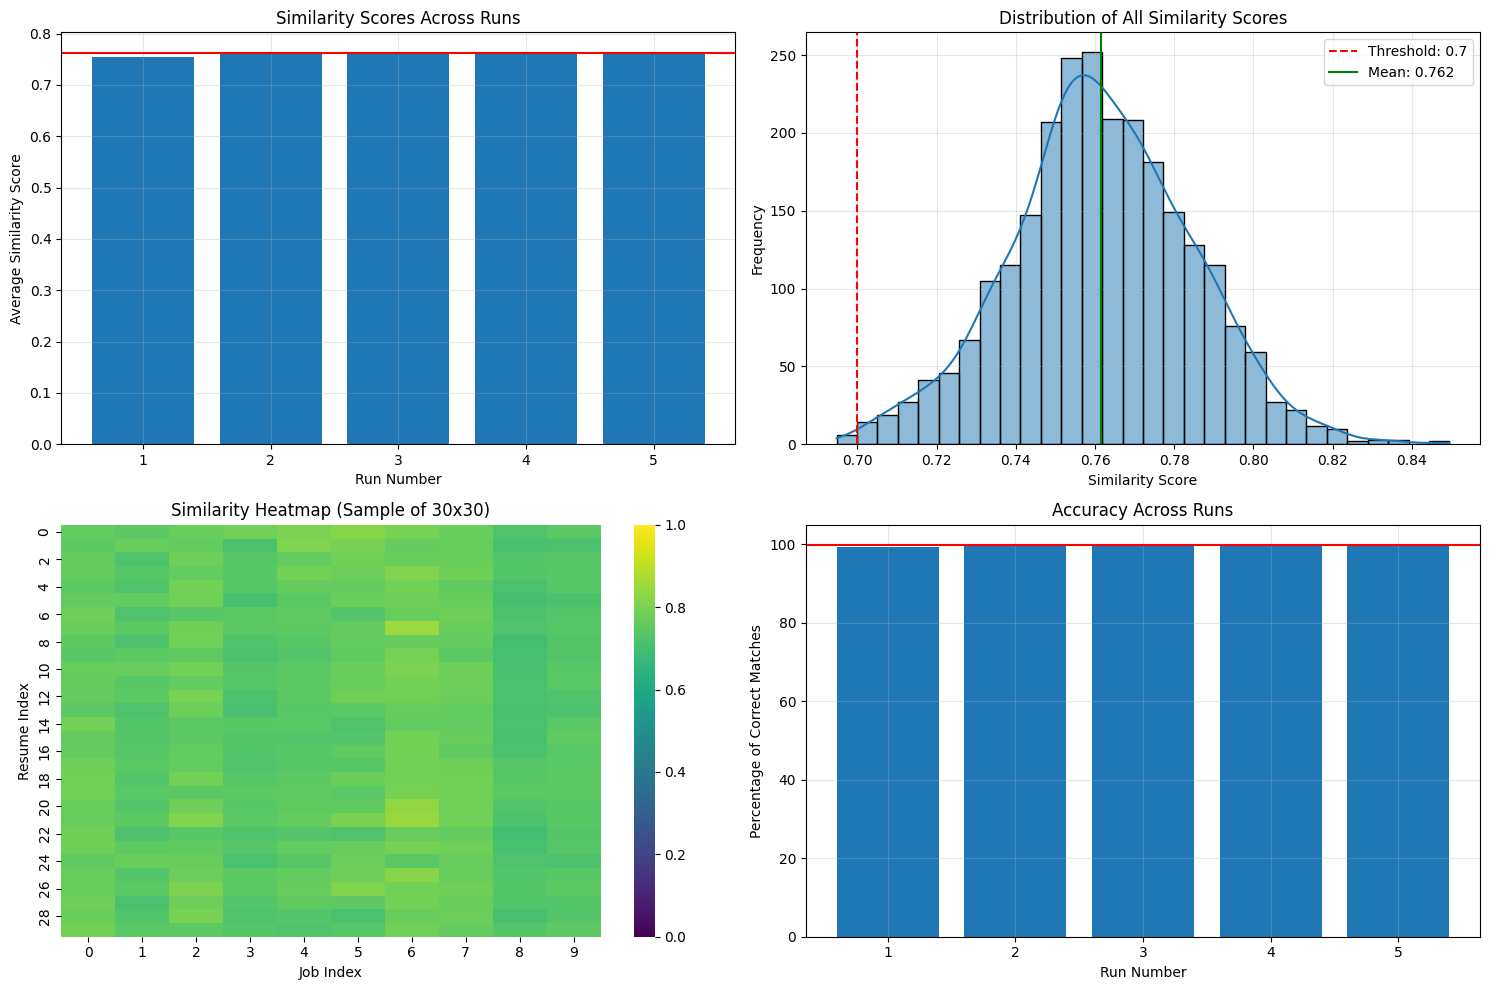


=== HIGH SIMILARITY MATCHES ===

Similarity Score: 0.849
Resume (processed): sap sa sql python power bi qlik sense tableau business analysis data visualization forecasting advanced analytics statistical analysis project management course economics emphasis statistic degree bac...
Resume (before preprocessing): ['SAP', 'SAS', 'SQL', 'Python', 'Power BI', 'Qlik Sense', 'Tableau'] ['Business Analysis', 'Data Visualization', 'Forecasting', 'Advanced Analytics', 'Statistical Analysis', 'Project Management'] [{'c...
Predicted Job category: Business Analyst...
--------------------------------------------------------------------------------

Similarity Score: 0.847
Resume (processed): business development expert 10 year experience b2b sale manufacturing industry digital transformation interested startup digitization business currently master bioinformatics lund university working i...
Resume (before preprocessing): Business Development Expert with over 10 years experience in B2B Sales, Manufa

In [ ]:
num_runs = 5
similarity_threshold = 0.7

metrics_df, combined_df = run_multiple_evaluations(
    resume_df_final,
    jobs_df_final,
    num_runs=num_runs,
    similarity_threshold=similarity_threshold
)

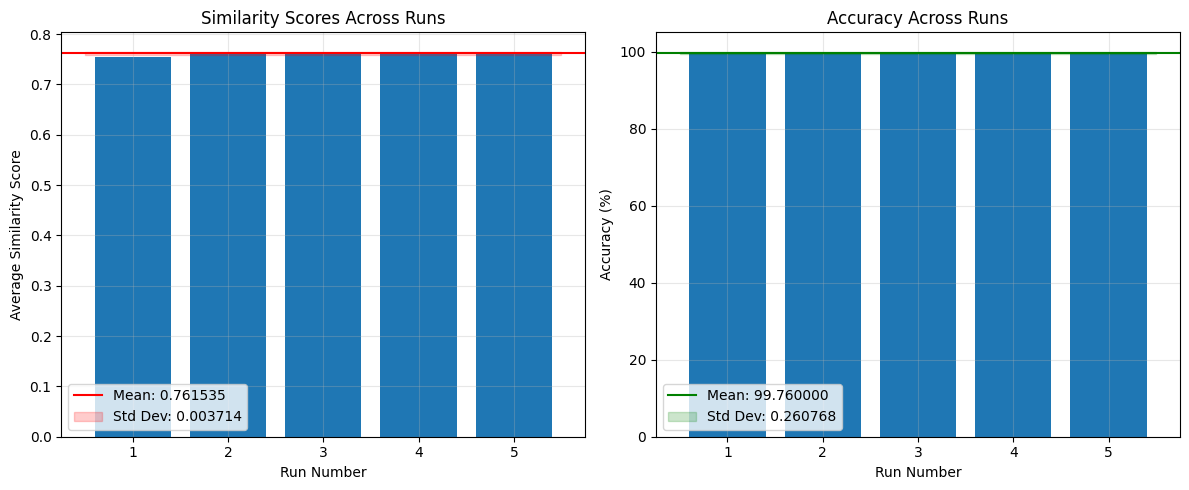

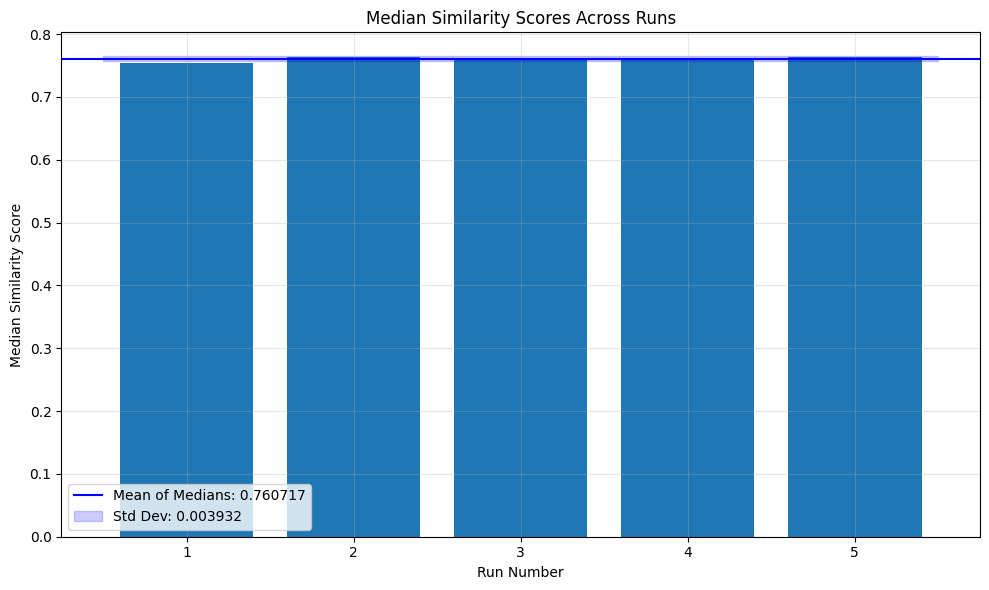

In [ ]:
# Plot the similarity results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(metrics_df['run'], metrics_df['avg_similarity'])
plt.axhline(y=metrics_df['avg_similarity'].mean(), color='r', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['avg_similarity'].mean() - metrics_df['avg_similarity'].std()]*2,
    [metrics_df['avg_similarity'].mean() + metrics_df['avg_similarity'].std()]*2,
    color='r', alpha=0.2, label=f'Std Dev: {metrics_df["avg_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

# Plot the accuracy results
plt.subplot(1, 2, 2)
plt.bar(metrics_df['run'], metrics_df['pct_correct_matches'])
plt.axhline(y=metrics_df['pct_correct_matches'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["pct_correct_matches"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['pct_correct_matches'].mean() - metrics_df['pct_correct_matches'].std()]*2,
    [metrics_df['pct_correct_matches'].mean() + metrics_df['pct_correct_matches'].std()]*2,
    color='g', alpha=0.2, label=f'Std Dev: {metrics_df["pct_correct_matches"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add a new plot for median similarity scores
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['run'], metrics_df['median_similarity'])
plt.axhline(y=metrics_df['median_similarity'].mean(), color='b', linestyle='-',
            label=f'Mean of Medians: {metrics_df["median_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['median_similarity'].mean() - metrics_df['median_similarity'].std()]*2,
    [metrics_df['median_similarity'].mean() + metrics_df['median_similarity'].std()]*2,
    color='b', alpha=0.2, label=f'Std Dev: {metrics_df["median_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Median Similarity Score')
plt.title('Median Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

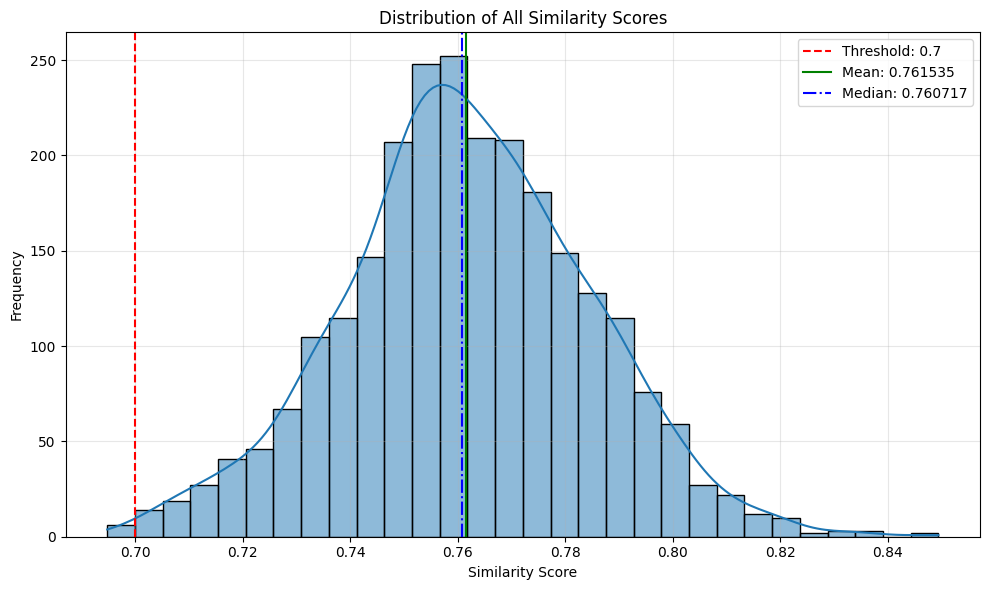

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['similarity_score'], bins=30, kde=True)
plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
plt.axvline(x=metrics_df['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.axvline(x=metrics_df['median_similarity'].mean(), color='b', linestyle='-.',
            label=f'Median: {metrics_df["median_similarity"].mean():.6f}')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2035955239.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=metrics_df['run'])


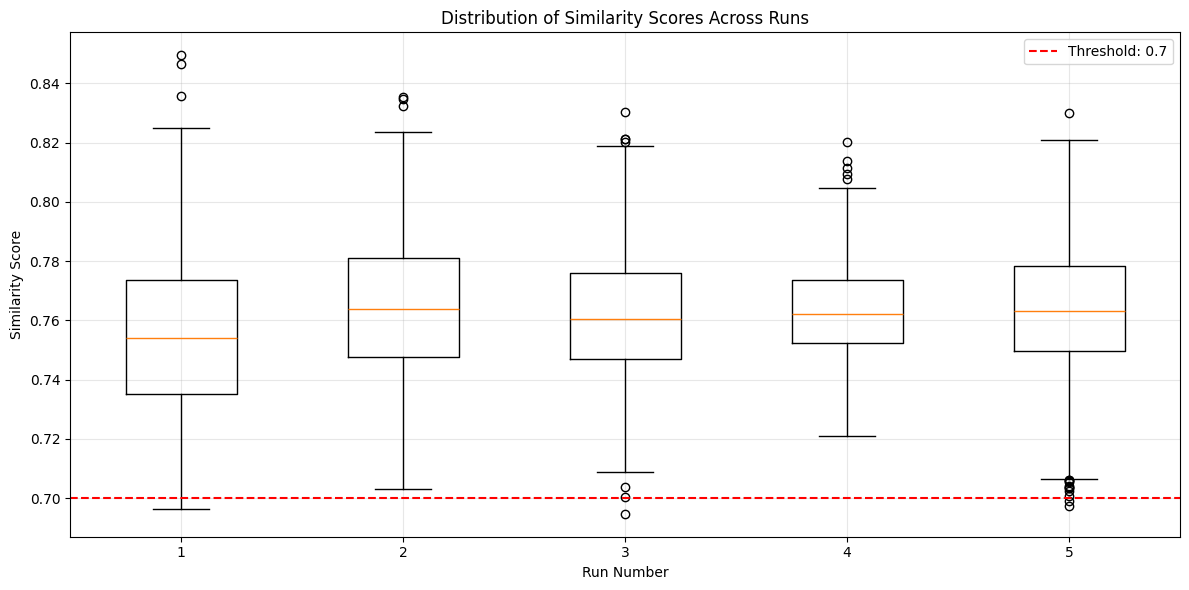

In [ ]:
# 3. Box plot of similarity scores across runs
plt.figure(figsize=(12, 6))
boxplot_data = [combined_df[combined_df['run'] == run]['similarity_score'] for run in metrics_df['run']]
plt.boxplot(boxplot_data, labels=metrics_df['run'])
plt.axhline(y=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
plt.xlabel('Run Number')
plt.ylabel('Similarity Score')
plt.title('Distribution of Similarity Scores Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


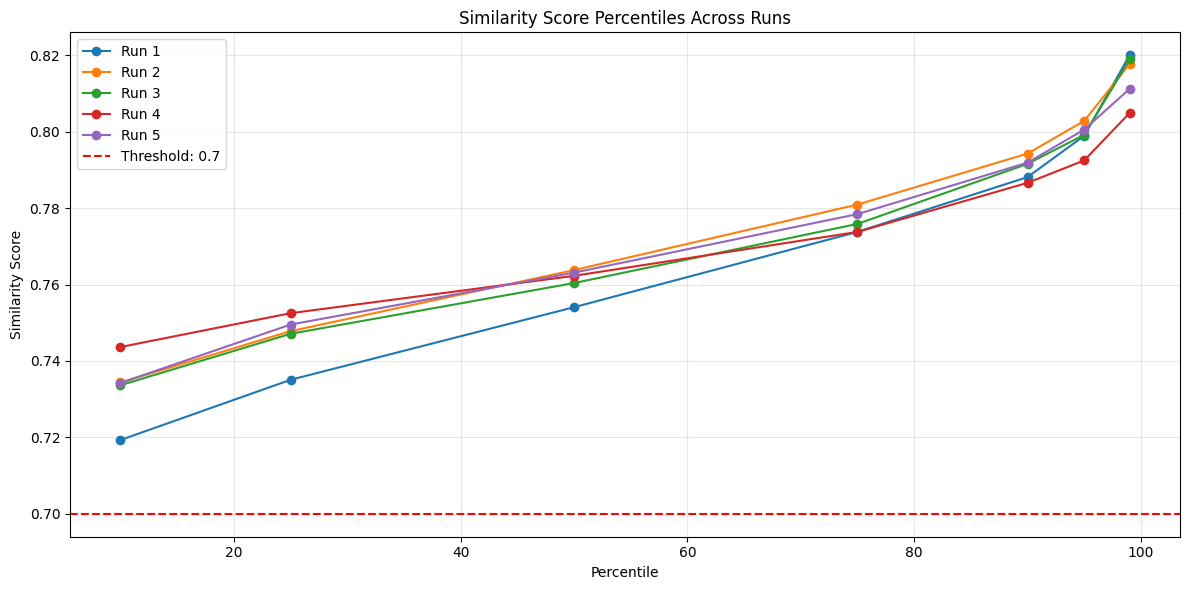

In [ ]:
# 4. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
plt.figure(figsize=(12, 6))
for run in metrics_df['run']:
    run_data = combined_df[combined_df['run'] == run]['similarity_score']
    percentile_values = np.percentile(run_data, percentiles)
    plt.plot(percentiles, percentile_values, marker='o', label=f'Run {run}')

plt.axhline(y=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
plt.xlabel('Percentile')
plt.ylabel('Similarity Score')
plt.title('Similarity Score Percentiles Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Extract wrong predictions
wrong_preds = combined_df[combined_df['is_correct'] == False]

# Check the distribution of their similarity scores
print("\n=== SIMILARITY SCORES OF WRONG PREDICTIONS ===")
print(wrong_preds['similarity_score'].describe())

# Lowest and highest scores among wrong predictions
print(f"Lowest wrong score: {wrong_preds['similarity_score'].min():.3f}")
print(f"Highest wrong score: {wrong_preds['similarity_score'].max():.3f}")


=== SIMILARITY SCORES OF WRONG PREDICTIONS ===
count    6.000000
mean     0.697221
std      0.001647
min      0.694751
25%      0.696477
50%      0.697094
75%      0.698584
max      0.699034
Name: similarity_score, dtype: float64
Lowest wrong score: 0.695
Highest wrong score: 0.699


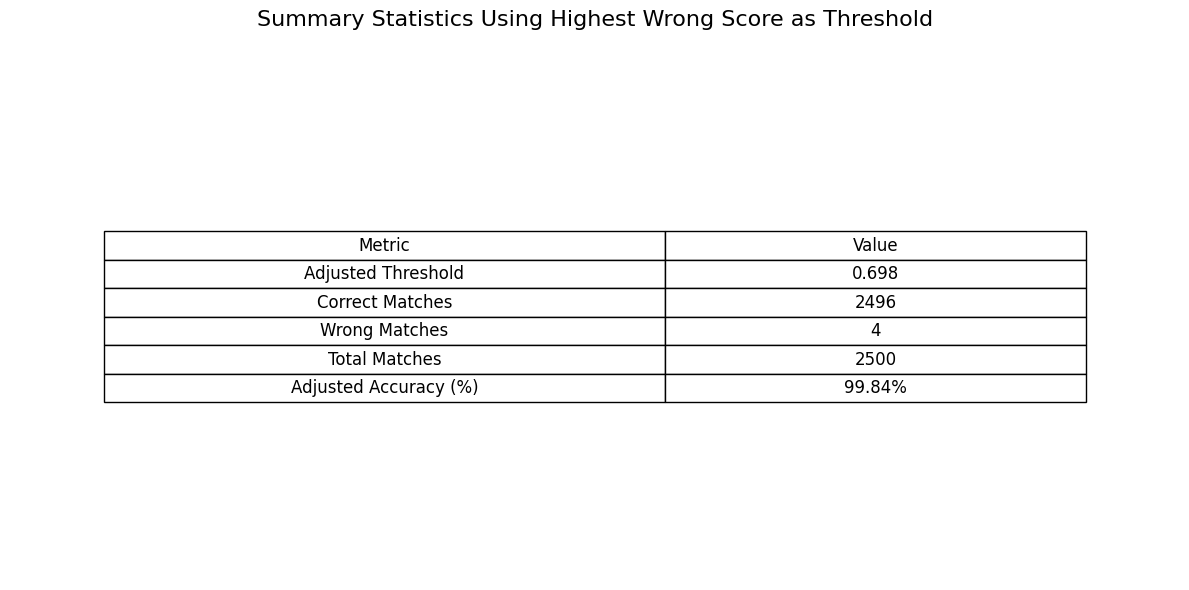

In [ ]:
# Set threshold to the highest wrong similarity score
#adjusted_threshold = wrong_preds['similarity_score'].max()
# Set threshold to highest wrong score
adjusted_threshold = 0.698

# Recompute correct/wrong matches based on adjusted threshold
combined_df['is_correct_adjusted'] = combined_df['similarity_score'] >= adjusted_threshold

# Count correct and wrong matches
num_correct = combined_df['is_correct_adjusted'].sum()
num_wrong = len(combined_df) - num_correct
accuracy_adjusted = num_correct / len(combined_df) * 100

# Summary table
plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Adjusted Threshold', f"{adjusted_threshold:.3f}"],
    ['Correct Matches', f"{num_correct}"],
    ['Wrong Matches', f"{num_wrong}"],
    ['Total Matches', f"{len(combined_df)}"],
    ['Adjusted Accuracy (%)', f"{accuracy_adjusted:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Summary Statistics Using Highest Wrong Score as Threshold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()